In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder

In [ ]:
df = pd.read_csv("../data/dataset.csv")
df = df.dropna()
# df = df.drop(["target_time"], axis=1)
df

,symbol,time,stock_lret,market_lret,excess_lret,stock_lret_mom_10,stock_lret_mom_20,stock_lret_mom_60,market_lret_mom_10,market_lret_mom_20,...,idio_lret_with_beta_10_vol_20,idio_lret_with_beta_10_vol_60,idio_lret_with_beta_20_vol_10,idio_lret_with_beta_20_vol_20,idio_lret_with_beta_20_vol_60,idio_lret_with_beta_60_vol_10,idio_lret_with_beta_60_vol_20,idio_lret_with_beta_60_vol_60,target,target_time
119,ACB,2017-06-29,0.006601,0.003518,0.003083,-0.015234,0.047147,0.037993,0.014593,0.039581,...,0.012742,0.012956,0.009255,0.012382,0.012983,0.009124,0.012206,0.013259,-0.002195,2017-06-30
120,ACB,2017-06-30,-0.002195,0.006097,-0.008293,-0.017430,0.049560,0.024473,0.019809,0.049717,...,0.012903,0.012928,0.009726,0.012749,0.013011,0.009345,0.012429,0.013262,0.017430,2017-07-03
121,ACB,2017-07-03,0.017430,0.003099,0.014331,-0.008602,0.062381,0.046417,0.015592,0.046502,...,0.013315,0.013074,0.010992,0.013026,0.013109,0.010878,0.012798,0.013383,-0.006501,2017-07-04
122,ACB,2017-07-04,-0.006501,-0.004297,-0.002203,-0.021506,0.035402,0.055880,0.009783,0.031741,...,0.012990,0.012743,0.010796,0.012845,0.012903,0.010651,0.012651,0.013078,0.010811,2017-07-05
123,ACB,2017-07-05,0.010811,0.003578,0.007233,0.006473,0.004310,0.082914,0.014117,0.032462,...,0.009071,0.012601,0.010124,0.009078,0.012725,0.009972,0.008960,0.012883,0.000000,2017-07-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53044,VRE,2025-12-24,0.011611,0.006003,0.005608,0.144100,0.023359,0.044255,0.036465,0.059188,...,0.021256,0.022810,0.019660,0.021024,0.022469,0.019852,0.021251,0.025077,-0.071780,2025-12-25
53045,VRE,2025-12-25,-0.071780,-0.022675,-0.049105,0.089128,-0.042495,0.015625,0.025541,0.034160,...,0.021555,0.022740,0.021873,0.021395,0.022144,0.022241,0.021690,0.024845,-0.007782,2025-12-26
53046,VRE,2025-12-26,-0.007782,-0.007516,-0.000266,0.153370,-0.067951,-0.023167,0.049117,0.022692,...,0.021551,0.022140,0.021696,0.021388,0.021688,0.021859,0.021607,0.024428,0.036814,2025-12-29
53047,VRE,2025-12-29,0.036814,0.014372,0.022442,0.138708,-0.049937,-0.052798,0.064024,0.030768,...,0.021745,0.022026,0.014133,0.021423,0.021567,0.014428,0.021629,0.023873,-0.012121,2025-12-30


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50159 entries, 119 to 53048
Data columns (total 52 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   symbol                         50159 non-null  object 
 1   time                           50159 non-null  object 
 2   stock_lret                     50159 non-null  float64
 3   market_lret                    50159 non-null  float64
 4   excess_lret                    50159 non-null  float64
 5   stock_lret_mom_10              50159 non-null  float64
 6   stock_lret_mom_20              50159 non-null  float64
 7   stock_lret_mom_60              50159 non-null  float64
 8   market_lret_mom_10             50159 non-null  float64
 9   market_lret_mom_20             50159 non-null  float64
 10  market_lret_mom_60             50159 non-null  float64
 11  excess_lret_mom_10             50159 non-null  float64
 12  excess_lret_mom_20             50159 non-null  fl

In [4]:
df.describe()

,stock_lret,market_lret,excess_lret,stock_lret_mom_10,stock_lret_mom_20,stock_lret_mom_60,market_lret_mom_10,market_lret_mom_20,market_lret_mom_60,excess_lret_mom_10,...,idio_lret_with_beta_10_vol_10,idio_lret_with_beta_10_vol_20,idio_lret_with_beta_10_vol_60,idio_lret_with_beta_20_vol_10,idio_lret_with_beta_20_vol_20,idio_lret_with_beta_20_vol_60,idio_lret_with_beta_60_vol_10,idio_lret_with_beta_60_vol_20,idio_lret_with_beta_60_vol_60,target
count,50159.000000,50159.000000,50159.000000,50159.000000,50159.000000,50159.000000,50159.000000,50159.000000,50159.000000,50159.000000,...,50159.000000,50159.000000,50159.000000,50159.000000,50159.000000,50159.000000,50159.000000,50159.000000,50159.000000,50159.000000
mean,0.000603,0.000375,0.000228,0.005933,0.011984,0.037156,0.003667,0.007347,0.022392,0.002266,...,0.013341,0.013737,0.014200,0.013769,0.014135,0.014560,0.014114,0.014487,0.014892,0.000576
std,0.021944,0.012342,0.017118,0.071700,0.102412,0.184320,0.042490,0.060168,0.106361,0.055240,...,0.006890,0.006162,0.005208,0.007036,0.006272,0.005289,0.007232,0.006432,0.005431,0.021160
min,-0.164622,-0.069639,-0.114685,-0.432595,-0.591249,-0.872745,-0.239379,-0.322040,-0.376093,-0.442909,...,0.000708,0.001142,0.000723,0.000874,0.000873,0.000504,0.001245,0.002163,0.002239,-0.164622
25%,-0.009040,-0.004204,-0.008656,-0.029389,-0.039482,-0.068725,-0.017044,-0.018588,-0.025379,-0.027974,...,0.008451,0.009335,0.010371,0.008760,0.009642,0.010695,0.008947,0.009927,0.010955,-0.009049
50%,0.000000,0.001402,-0.001180,0.004329,0.008837,0.023571,0.008361,0.012725,0.025499,-0.002311,...,0.011943,0.012615,0.013446,0.012325,0.012986,0.013785,0.012652,0.013298,0.014085,0.000000
75%,0.009975,0.006535,0.007574,0.042101,0.064202,0.132519,0.029450,0.044625,0.087843,0.027474,...,0.016671,0.016961,0.017207,0.017233,0.017541,0.017664,0.017688,0.017925,0.018064,0.009973
max,1.304007,0.280823,1.023184,1.371445,1.386581,1.386581,0.289638,0.305230,0.378491,1.169720,...,0.101221,0.072675,0.051487,0.116402,0.087288,0.051752,0.116268,0.087723,0.064391,0.104649


# Train/Val/Test

In [5]:
def split_time_series(df,
                      train_start='2017-01-01',
                      train_end='2023-01-01',
                      val_end='2024-01-01',
                      test_end=None,
                      time_col='time'):
    
    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col])
    df = df.sort_values(by=[time_col])

    train_df = df[
        (df[time_col] >= train_start) &
        (df[time_col] < train_end)
    ]

    val_df = df[
        (df[time_col] >= train_end) &
        (df[time_col] < val_end)
    ]

    if test_end is not None:
        test_df = df[
            (df[time_col] >= val_end) &
            (df[time_col] < test_end)
        ]
    else:
        test_df = df[df[time_col] >= val_end]

    return train_df, val_df, test_df

In [6]:
train_df, val_df, test_df = split_time_series(df)
train_df.shape, val_df.shape, test_df.shape

((32231, 52), (5976, 52), (11952, 52))

In [7]:
print(train_df['time'].min(), train_df['time'].max())
print(val_df['time'].min(), val_df['time'].max())
print(test_df['time'].min(), test_df['time'].max())

2017-06-29 00:00:00 2022-12-30 00:00:00
2023-01-03 00:00:00 2023-12-29 00:00:00
2024-01-02 00:00:00 2025-12-30 00:00:00


In [8]:
print(train_df["symbol"].nunique())
print(val_df["symbol"].nunique())
print(test_df["symbol"].nunique())

24
24
24


In [9]:
train_df.describe()

,time,stock_lret,market_lret,excess_lret,stock_lret_mom_10,stock_lret_mom_20,stock_lret_mom_60,market_lret_mom_10,market_lret_mom_20,market_lret_mom_60,...,idio_lret_with_beta_10_vol_10,idio_lret_with_beta_10_vol_20,idio_lret_with_beta_10_vol_60,idio_lret_with_beta_20_vol_10,idio_lret_with_beta_20_vol_20,idio_lret_with_beta_20_vol_60,idio_lret_with_beta_60_vol_10,idio_lret_with_beta_60_vol_20,idio_lret_with_beta_60_vol_60,target
count,32231,32231.000000,32231.000000,32231.000000,32231.000000,32231.000000,32231.000000,32231.000000,32231.000000,32231.000000,...,32231.000000,32231.000000,32231.000000,32231.000000,32231.000000,32231.000000,32231.000000,32231.000000,32231.000000,32231.000000
mean,2020-04-24 16:24:30.782786560,0.000496,0.000165,0.000330,0.005025,0.010499,0.030919,0.001710,0.003823,0.011991,...,0.014340,0.014751,0.015171,0.014801,0.015175,0.015547,0.015165,0.015548,0.015896,0.000482
min,2017-06-29 00:00:00,-0.164622,-0.069639,-0.114685,-0.432595,-0.591249,-0.872745,-0.239379,-0.322040,-0.376093,...,0.000708,0.001142,0.000723,0.000874,0.000873,0.000504,0.001402,0.002326,0.002239,-0.164622
25%,2018-12-19 00:00:00,-0.009942,-0.004436,-0.009343,-0.033543,-0.045948,-0.084150,-0.019943,-0.025153,-0.045290,...,0.009282,0.010215,0.011380,0.009656,0.010553,0.011705,0.009862,0.010837,0.012008,-0.009940
50%,2020-04-29 00:00:00,0.000000,0.001218,-0.001120,0.004221,0.008853,0.019570,0.006921,0.010011,0.024172,...,0.012878,0.013527,0.014448,0.013307,0.013956,0.014821,0.013680,0.014308,0.015113,0.000000
75%,2021-08-31 00:00:00,0.010875,0.006603,0.008461,0.045747,0.069661,0.138423,0.029562,0.045935,0.089030,...,0.017787,0.018120,0.018177,0.018339,0.018626,0.018614,0.018925,0.018973,0.018984,0.010912
max,2022-12-30 00:00:00,1.304007,0.280823,1.023184,1.371445,1.386581,1.386581,0.289638,0.305230,0.378491,...,0.101221,0.072675,0.051487,0.116402,0.087288,0.051752,0.116268,0.087723,0.064391,0.104649
std,NaN,0.023788,0.012997,0.018480,0.078198,0.112210,0.199821,0.046612,0.066569,0.118498,...,0.007164,0.006359,0.005289,0.007300,0.006465,0.005365,0.007521,0.006648,0.005538,0.022677


# Scaling

In [10]:
exclude_cols = ['time', 'symbol', 'target', 'target_time']
feature_cols = [c for c in train_df.columns if c not in exclude_cols]
feature_cols = [
    'idio_lret_with_beta_10',
    'idio_lret_with_beta_20', 
    'idio_lret_with_beta_60',
    'excess_lret',
    'stock_lret',
    'stock_lret_vol_10',
    'stock_lret_vol_20',
    'market_lret_mom_10',
    'excess_lret_vol_10'
]

train_df = train_df.copy()
val_df   = val_df.copy()
test_df  = test_df.copy()

# Scaler riêng cho features
feature_scaler = StandardScaler()
train_df[feature_cols] = feature_scaler.fit_transform(train_df[feature_cols])
val_df[feature_cols]   = feature_scaler.transform(val_df[feature_cols])
test_df[feature_cols]  = feature_scaler.transform(test_df[feature_cols])

# Scaler riêng cho target
target_scaler = StandardScaler()
train_df[['target']] = target_scaler.fit_transform(train_df[['target']])
val_df[['target']]   = target_scaler.transform(val_df[['target']])
test_df[['target']]  = target_scaler.transform(test_df[['target']])

In [11]:
train_df.describe()

,time,stock_lret,market_lret,excess_lret,stock_lret_mom_10,stock_lret_mom_20,stock_lret_mom_60,market_lret_mom_10,market_lret_mom_20,market_lret_mom_60,...,idio_lret_with_beta_10_vol_10,idio_lret_with_beta_10_vol_20,idio_lret_with_beta_10_vol_60,idio_lret_with_beta_20_vol_10,idio_lret_with_beta_20_vol_20,idio_lret_with_beta_20_vol_60,idio_lret_with_beta_60_vol_10,idio_lret_with_beta_60_vol_20,idio_lret_with_beta_60_vol_60,target
count,32231,3.223100e+04,32231.000000,3.223100e+04,32231.000000,32231.000000,32231.000000,3.223100e+04,32231.000000,32231.000000,...,32231.000000,32231.000000,32231.000000,32231.000000,32231.000000,32231.000000,32231.000000,32231.000000,32231.000000,3.223100e+04
mean,2020-04-24 16:24:30.782786560,1.763626e-18,0.000165,-1.190447e-17,0.005025,0.010499,0.030919,-3.527251e-17,0.003823,0.011991,...,0.014340,0.014751,0.015171,0.014801,0.015175,0.015547,0.015165,0.015548,0.015896,-3.527251e-18
min,2017-06-29 00:00:00,-6.941437e+00,-0.069639,-6.223870e+00,-0.432595,-0.591249,-0.872745,-5.172322e+00,-0.322040,-0.376093,...,0.000708,0.001142,0.000723,0.000874,0.000873,0.000504,0.001402,0.002326,0.002239,-7.280799e+00
25%,2018-12-19 00:00:00,-4.387755e-01,-0.004436,-5.234292e-01,-0.033543,-0.045948,-0.084150,-4.645395e-01,-0.025153,-0.045290,...,0.009282,0.010215,0.011380,0.009656,0.010553,0.011705,0.009862,0.010837,0.012008,-4.595752e-01
50%,2020-04-29 00:00:00,-2.083212e-02,0.001218,-7.848385e-02,0.004221,0.008853,0.019570,1.117907e-01,0.010011,0.024172,...,0.012878,0.013527,0.014448,0.013307,0.013956,0.014821,0.013680,0.014308,0.015113,-2.123649e-02
75%,2021-08-31 00:00:00,4.363638e-01,0.006603,4.399758e-01,0.045747,0.069661,0.138423,5.975342e-01,0.045935,0.089030,...,0.017787,0.018120,0.018177,0.018339,0.018626,0.018614,0.018925,0.018973,0.018984,4.599836e-01
max,2022-12-30 00:00:00,5.479881e+01,0.280823,5.535020e+01,1.371445,1.386581,1.386581,6.177199e+00,0.305230,0.378491,...,0.101221,0.072675,0.051487,0.116402,0.087288,0.051752,0.116268,0.087723,0.064391,4.593594e+00
std,NaN,1.000016e+00,0.012997,1.000016e+00,0.078198,0.112210,0.199821,1.000016e+00,0.066569,0.118498,...,0.007164,0.006359,0.005289,0.007300,0.006465,0.005365,0.007521,0.006648,0.005538,1.000016e+00


# Encoding

In [12]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

symbol_train = ohe.fit_transform(train_df[['symbol']])
symbol_val   = ohe.transform(val_df[['symbol']])
symbol_test  = ohe.transform(test_df[['symbol']])

# Create new cols
symbol_cols = [f"symbol_{cat}" for cat in ohe.categories_[0]]

# train_df[symbol_cols] = symbol_train
# val_df[symbol_cols]   = symbol_val
# test_df[symbol_cols]  = symbol_test

# train_df.head(5)

In [13]:
le = LabelEncoder()

train_df['symbol_id'] = le.fit_transform(train_df['symbol'])
val_df['symbol_id']   = le.transform(val_df['symbol'])
test_df['symbol_id']  = le.transform(test_df['symbol'])

n_symbols = len(le.classes_)
print(f"Số symbols: {n_symbols}")

train_df.head(5)

Số symbols: 24


,symbol,time,stock_lret,market_lret,excess_lret,stock_lret_mom_10,stock_lret_mom_20,stock_lret_mom_60,market_lret_mom_10,market_lret_mom_20,...,idio_lret_with_beta_10_vol_60,idio_lret_with_beta_20_vol_10,idio_lret_with_beta_20_vol_20,idio_lret_with_beta_20_vol_60,idio_lret_with_beta_60_vol_10,idio_lret_with_beta_60_vol_20,idio_lret_with_beta_60_vol_60,target,target_time,symbol_id
119,ACB,2017-06-29,0.256656,0.003518,0.148961,-0.015234,0.047147,0.037993,0.276378,0.039581,...,0.012956,0.009255,0.012382,0.012983,0.009124,0.012206,0.013259,-0.118050,2017-06-30,0
4610,CTG,2017-06-29,-0.020832,0.003518,-0.208225,-0.014517,0.077141,0.113014,0.276378,0.039581,...,0.011074,0.010283,0.011926,0.011072,0.010519,0.011774,0.011692,0.176736,2017-06-30,2
6858,DGC,2017-06-29,1.712996,0.003518,2.023575,-0.008621,0.033752,-0.118264,0.276378,0.039581,...,0.021071,0.019072,0.018628,0.021406,0.018791,0.019631,0.021509,-0.148689,2017-06-30,3
9100,FPT,2017-06-29,0.120596,0.003518,-0.026178,0.023790,0.067734,0.161877,0.276378,0.039581,...,0.009178,0.013583,0.012258,0.009645,0.014060,0.012374,0.009900,0.310748,2017-06-30,4
11348,GAS,2017-06-29,-0.020832,0.003518,-0.208225,0.024559,0.045770,0.076243,0.276378,0.039581,...,0.010762,0.009680,0.009434,0.010827,0.010128,0.009611,0.011093,0.750023,2017-06-30,5


# Create sequences

In [14]:
def create_sequences(df, window=20, feature_cols=None, sym_cols="symbol_id", target_col='target'):
    X, y, sym, meta = [], [], [], []
    
    for symbol, sub_df in df.groupby('symbol'):
        sub_df = sub_df.sort_values('time').reset_index(drop=True)

        values_x = sub_df[feature_cols].values
        values_y = sub_df[target_col].values
        values_sym = sub_df[sym_cols].values
        
        for i in range(len(sub_df) - window):
            X.append(values_x[i : i + window])
            y.append(values_y[i + window - 1])
            sym.append(values_sym[i])  
            meta.append({
                'symbol': symbol,
                'time': sub_df['target_time'].iloc[i + window - 1]
            })
    
    X = np.array(X)
    y = np.array(y)
    sym = np.array(sym)  
    meta_df = pd.DataFrame(meta)
    
    return X, y, sym, meta_df

In [15]:
X_train, y_train, sym_train, meta_train = create_sequences(train_df, feature_cols=feature_cols)
X_val,   y_val,   sym_val,   meta_val   = create_sequences(val_df,   feature_cols=feature_cols)
X_test,  y_test,  sym_test,  meta_test  = create_sequences(test_df,  feature_cols=feature_cols)

print(X_train.shape, y_train.shape, sym_train.shape)
print(X_val.shape,   y_val.shape,   sym_val.shape)
print(X_test.shape,  y_test.shape,  sym_test.shape)

(31751, 20, 9) (31751,) (31751,)
(5496, 20, 9) (5496,) (5496,)
(11472, 20, 9) (11472,) (11472,)


# Building LSTM

In [16]:
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import LSTM, Dense, Dropout, Embedding, Flatten, Concatenate, RepeatVector
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

c:\Users\manh\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [17]:
n_features   = X_train.shape[2]      
window       = X_train.shape[1]      
embed_dim    = min(50, n_symbols // 2) 

In [18]:
# Inputs
seq_input    = Input(shape=(window, n_features), name='seq_input')
symbol_input = Input(shape=(1,),                 name='symbol_input')

# Symbol Embedding
emb      = Embedding(input_dim=n_symbols, output_dim=embed_dim, name='symbol_emb')(symbol_input)
emb_flat = Flatten(name='emb_flat')(emb)                        # (batch, embed_dim)

# ── Concat embedding vào TRƯỚC LSTM ─────────────────────────────────────────
# Repeat emb_flat theo time axis để khớp với (batch, window, embed_dim)
emb_rep  = RepeatVector(window, name='emb_repeat')(emb_flat)    # (batch, window, embed_dim)
lstm_in  = Concatenate(axis=-1, name='concat_input')([seq_input, emb_rep])
#          shape: (batch, window, n_features + embed_dim)

# ── Stacked LSTM ─────────────────────────────────────────────────────────────
x = LSTM(128, return_sequences=True,  name='lstm_1')(lstm_in)
x = Dropout(0.2,                      name='drop_1')(x)
x = LSTM(64,  return_sequences=True,  name='lstm_2')(x)
x = Dropout(0.2,                      name='drop_2')(x)
x = LSTM(32,  return_sequences=False, name='lstm_3')(x)
x = Dropout(0.2,                      name='drop_3')(x)

# ── Concat embedding vào SAU LSTM → FNN ──────────────────────────────────────
combined = Concatenate(name='concat_output')([x, emb_flat])     # (batch, 32 + embed_dim)
x = Dense(64,  activation='relu', name='dense_1')(combined)
x = Dropout(0.2,                  name='drop_4')(x)
x = Dense(32,  activation='relu', name='dense_2')(x)
output = Dense(1,                 name='output')(x)

model = Model(inputs=[seq_input, symbol_input], outputs=output)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ symbol_input        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ symbol_emb          │ (None, 1, 12)     │        288 │ symbol_input[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_flat (Flatten)  │ (None, 12)        │          0 │ symbol_emb[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seq_input           │ (None, 20, 9)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_repeat          │ (None, 20, 12)    │          0 │ emb_flat[0][0]    │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_input        │ (None, 20, 21)    │          0 │ seq_input[0][0],  │
│ (Concatenate)       │                   │            │ emb_repeat[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 20, 128)   │     76,800 │ concat_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_1 (Dropout)    │ (None, 20, 128)   │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 20, 64)    │     49,408 │ drop_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_2 (Dropout)    │ (None, 20, 64)    │          0 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 32)        │     12,416 │ drop_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_3 (Dropout)    │ (None, 32)        │          0 │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_output       │ (None, 44)        │          0 │ drop_3[0][0],     │
│ (Concatenate)       │                   │            │ emb_flat[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      2,880 │ concat_output[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_4 (Dropout)    │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ drop_4[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         33 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 143,905 (562.13 KB)

 Trainable params: 143,905 (562.13 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
def directional_loss(y_true, y_pred):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    direction_penalty = tf.reduce_mean(
        tf.nn.relu(-y_true * y_pred)  # phạt khi predict sai dấu
    )
    return mse + 0.5 * direction_penalty

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=directional_loss,
    metrics=['mae']
)

In [20]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

history = model.fit(
    x={'seq_input': X_train, 'symbol_input': sym_train},
    y=y_train,
    validation_data=(
        {'seq_input': X_val, 'symbol_input': sym_val}, y_val
    ),
    epochs=50,
    batch_size=512,
    callbacks=callbacks
)

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 209ms/step - loss: 1.0053 - mae: 0.6886 - val_loss: 0.6159 - val_mae: 0.5553 - learning_rate: 0.0010
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 194ms/step - loss: 1.0042 - mae: 0.6884 - val_loss: 0.6153 - val_mae: 0.5542 - learning_rate: 0.0010
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 193ms/step - loss: 1.0026 - mae: 0.6880 - val_loss: 0.6150 - val_mae: 0.5547 - learning_rate: 0.0010
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 193ms/step - loss: 1.0026 - mae: 0.6879 - val_loss: 0.6144 - val_mae: 0.5548 - learning_rate: 0.0010
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 196ms/step - loss: 1.0025 - mae: 0.6881 - val_loss: 0.6146 - val_mae: 0.5549 - learning_rate: 0.0010
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 216ms/step - loss: 1.0016 - mae: 0.6880 - val_loss: 0.6150 - val_mae: 0.5548 - learning_rate: 0.0010
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 210ms/step - loss: 1.0015 - mae: 0.6878 - val_loss: 0.6176 - val_mae: 0.5560 - learning_rate: 0.0010

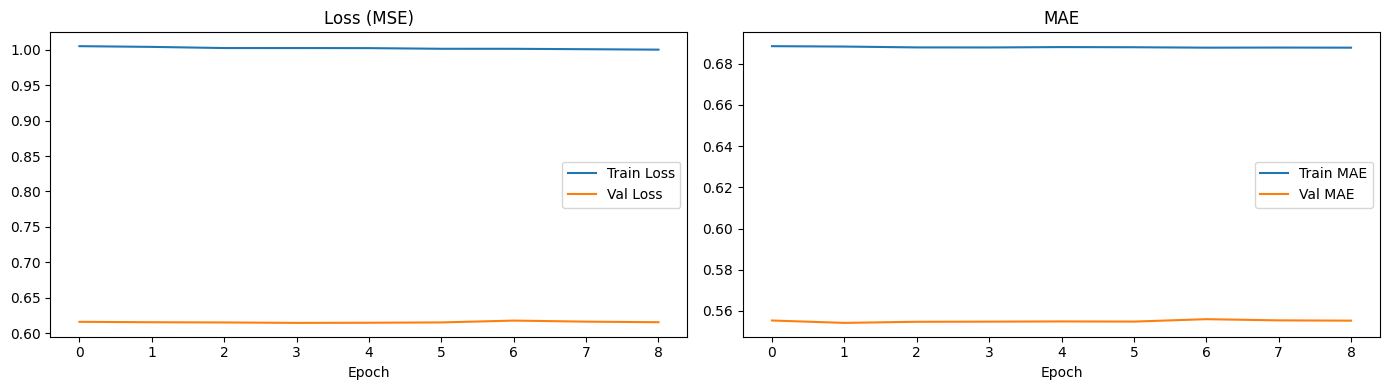

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss (MSE)')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['mae'],     label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_title('MAE')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [22]:
test_loss, test_mae = model.evaluate(
    x={'seq_input': X_test, 'symbol_input': sym_test},
    y=y_test,
    batch_size=512,
    verbose=1
)
print(f"Test MSE : {test_loss:.6f}")
print(f"Test MAE : {test_mae:.6f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - loss: 0.6608 - mae: 0.5383
Test MSE : 0.660817
Test MAE : 0.538322


In [23]:
y_pred_scaled = model.predict(
    {'seq_input': X_test, 'symbol_input': sym_test},
    batch_size=512
)

y_pred = target_scaler.inverse_transform(y_pred_scaled)          # (N, 1)
y_true = target_scaler.inverse_transform(y_test.reshape(-1, 1))  # (N, 1)

23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step


In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse  = mean_squared_error(y_true, y_pred)
mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mse)

print(f"RMSE : {rmse:.6f}")
print(f"MAE  : {mae:.6f}")

# Direction accuracy
direction_acc = np.mean(np.sign(y_pred) == np.sign(y_true))
print(f"Direction Accuracy: {direction_acc:.4f}")

RMSE : 0.018427
MAE  : 0.012207
Direction Accuracy: 0.4603


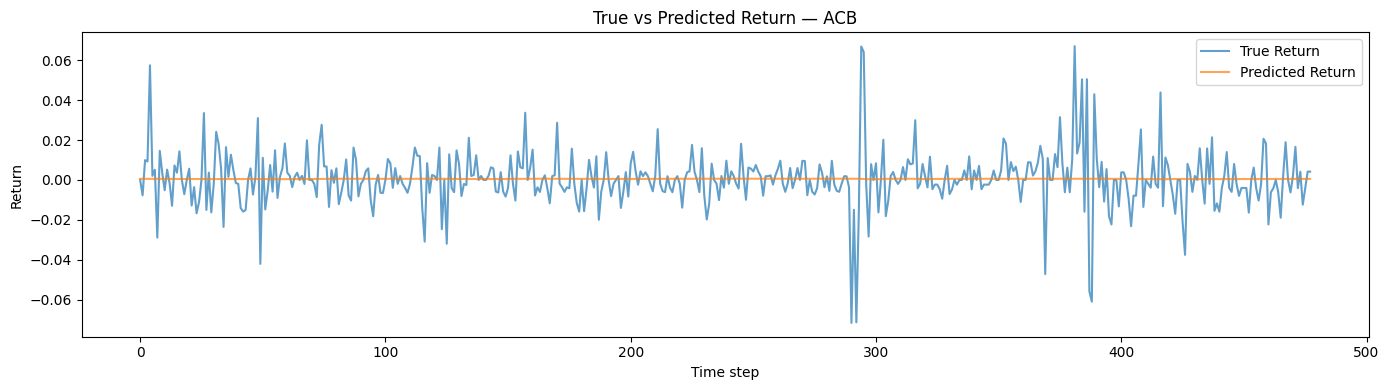

In [25]:
sample_symbol = le.classes_[0]
mask = meta_test['symbol'] == sample_symbol

plt.figure(figsize=(14, 4))
plt.plot(y_true[mask],          label='True Return',      alpha=0.7)
plt.plot(y_pred[mask.values],   label='Predicted Return', alpha=0.7)
plt.title(f'True vs Predicted Return — {sample_symbol}')
plt.xlabel('Time step')
plt.ylabel('Return')
plt.legend()
plt.tight_layout()
plt.show()

y_true mean : 0.000874
y_pred mean : 0.000469
y_true std  : 0.018418
y_pred std  : 0.000102
Pearson  r  : -0.0376  (p=0.0001)
Spearman r  : -0.0088  (p=0.3483)


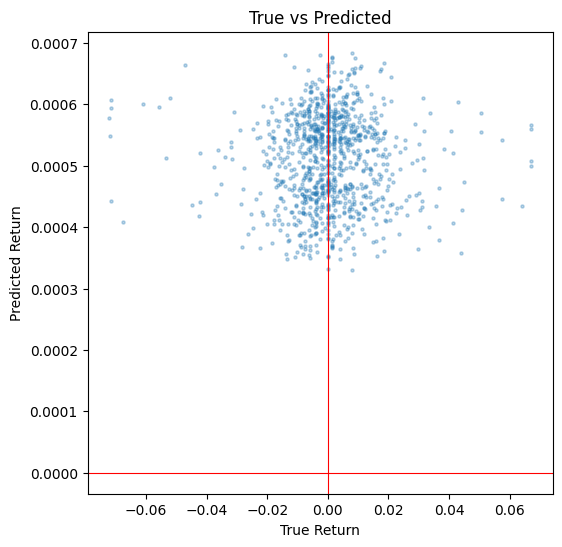

In [26]:
print(f"y_true mean : {y_true.mean():.6f}")
print(f"y_pred mean : {y_pred.mean():.6f}")
print(f"y_true std  : {y_true.std():.6f}")
print(f"y_pred std  : {y_pred.std():.6f}")

# Xem thử correlation
from scipy.stats import pearsonr, spearmanr
pearson_r,  p1 = pearsonr(y_true.flatten(),  y_pred.flatten())
spearman_r, p2 = spearmanr(y_true.flatten(), y_pred.flatten())
print(f"Pearson  r  : {pearson_r:.4f}  (p={p1:.4f})")
print(f"Spearman r  : {spearman_r:.4f}  (p={p2:.4f})")

# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(y_true[:1000], y_pred[:1000], alpha=0.3, s=5)
plt.axhline(0, color='r', linewidth=0.8)
plt.axvline(0, color='r', linewidth=0.8)
plt.xlabel('True Return')
plt.ylabel('Predicted Return')
plt.title('True vs Predicted')
plt.show()

In [27]:
# 1. Target có thực sự có signal không?
print("Autocorrelation của return (lag 1-5):")
for lag in range(1, 6):
    corr = pd.Series(y_true.flatten()).autocorr(lag=lag)
    print(f"  lag {lag}: {corr:.4f}")

# 2. Feature có correlate với target không?
feature_target_corr = pd.DataFrame(
    X_train[:, -1, :],  # timestep cuối
    columns=feature_cols
)
feature_target_corr['target'] = y_train
print("\nTop 10 features correlate với target:")
print(feature_target_corr.corr()['target'].abs().sort_values(ascending=False).head(10))

Autocorrelation của return (lag 1-5):
  lag 1: 0.0925
  lag 2: -0.0268
  lag 3: -0.0210
  lag 4: -0.0605
  lag 5: 0.0524

Top 10 features correlate với target:
target                    1.000000
idio_lret_with_beta_10    0.052836
idio_lret_with_beta_20    0.050277
idio_lret_with_beta_60    0.045592
excess_lret               0.039140
stock_lret                0.036654
stock_lret_vol_10         0.028851
stock_lret_vol_20         0.025780
market_lret_mom_10        0.025541
excess_lret_vol_10        0.024324
Name: target, dtype: float64
